In [5]:
## Importing our classes, modules and functions

In [102]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 73.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 58.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [matplotlib]5 [matplotlib]


In [1]:
import torch
import torch.nn as nn
from torchvision import datasets
from torchvision.transforms import v2
from torch.utils.data import DataLoader, Subset

In [2]:
## Downloading the data in root directory

In [8]:
from pathlib import Path                                              # Path gives a cleaner way to work with file and folder paths

# Dataset has now been shifted to Persisted Storage on the POD
data_root = Path("/workspace/data/imagenet100")

train_dirs = [
    data_root / "train.X1",
    data_root / "train.X2",
    data_root / "train.X3",
    data_root / "train.X4"
]

val_dir = data_root / "val.X"

checkpoint_dir = Path("/workspace/checkpoints")                         # save model checkpoints here, like model weights, optimizer state, epoch number, etc
output_dir = Path("/workspace/outputs")                                  # save model output here, training_history, loss_curve, confusion matrix, predictions
 
checkpoint_dir.mkdir(parents=True, exist_ok = True)                     # "mkdir" = make directory if it already does not exist
output_dir.mkdir(parents=True, exist_ok=True)                           # "parents=True" allows to create the parent directory /workspace it that also does not exist
                                                                        # "exist_ok=True" 

print("Dataset directory:", data_root)
print("Exists:", data_root.exists())
print("Dataset:", data_root)
print("Train folders:", train_dirs)
print("Validation:", val_dir)

Dataset directory: /workspace/data/imagenet100
Exists: True
Dataset: /workspace/data/imagenet100
Train folders: [PosixPath('/workspace/data/imagenet100/train.X1'), PosixPath('/workspace/data/imagenet100/train.X2'), PosixPath('/workspace/data/imagenet100/train.X3'), PosixPath('/workspace/data/imagenet100/train.X4')]
Validation: /workspace/data/imagenet100/val.X


In [10]:
train_dir = train_dirs[0]                                                  # take the first index from the above list

classes = sorted([x.name                                                   # returns "/workspace/data/imagenet100/train.X1/n0123456" and x.name stores only "n0123456"
                  for x in train_dir.iterdir()                             # iterate through the above train_dir i.e train.X1, iterdir() gives us path objects to each folder inside train.X1
                  if x.is_dir()])                                          # only keep the ones that are directories like n0123456/
                                                                           # finally sorting alphabetically

print("Number of classes in X1:", len(classes))                            # if each folder represents a class, it gives us the number of classes in each folder
print("First 10 classes:", classes[:10])

first_class = train_dir / classes[0]                                       # having a look inside the first class

images = list(first_class.iterdir())                                       # the list of path objects to all images in the first class

print("Images in first class:", len(images))
print("Example:", images[:3])

Number of classes in X1: 25
First 10 classes: ['n01440764', 'n01484850', 'n01494475', 'n01531178', 'n01632777', 'n01665541', 'n01687978', 'n01695060', 'n01749939', 'n01775062']
Images in first class: 1301
Example: [PosixPath('/workspace/data/imagenet100/train.X1/n01440764/.ipynb_checkpoints'), PosixPath('/workspace/data/imagenet100/train.X1/n01440764/n01440764_9981.JPEG'), PosixPath('/workspace/data/imagenet100/train.X1/n01440764/n01440764_9973.JPEG')]


In [11]:
from pathlib import Path

data_root = Path("/workspace/data/imagenet100")

for folder_name in ["train.X1", "train.X2", "train.X3", "train.X4", "val.X"]:
    
    folder = data_root / folder_name
    
    classes = [
        x for x in folder.iterdir()
        if x.is_dir()
    ]
    
    print(f"{folder_name}: {len(classes)} class folders")
    print("  Examples:", [x.name for x in classes[:5]])

train.X1: 25 class folders
  Examples: ['n02037110', 'n02018795', 'n02012849', 'n02007558', 'n01984695']
train.X2: 25 class folders
  Examples: ['n02077923', 'n02058221', 'n02028035', 'n02027492', 'n02018207']
train.X3: 25 class folders
  Examples: ['n02013706', 'n02011460', 'n02006656', 'n02002556', 'n01968897']
train.X4: 25 class folders
  Examples: ['n02051845', 'n01986214', 'n01985128', 'n01978287', 'n01943899']
val.X: 100 class folders
  Examples: ['n02077923', 'n02058221', 'n02051845', 'n02037110', 'n02028035']


In [12]:
import json

labels_path = data_root / "Labels.json"

with open(labels_path, "r") as f:
    labels = json.load(f)

print(type(labels))
print(list(labels.items())[:5] if isinstance(labels, dict) else labels[:5])

<class 'dict'>
[('n01968897', 'chambered nautilus, pearly nautilus, nautilus'), ('n01770081', 'harvestman, daddy longlegs, Phalangium opilio'), ('n01818515', 'macaw'), ('n02011460', 'bittern'), ('n01496331', 'electric ray, crampfish, numbfish, torpedo')]


In [8]:
## Building the class mapping

In [14]:
from pathlib import Path

data_root = Path("/workspace/data/imagenet100")

train_folders = [
    data_root/"train.X1",
    data_root/"train.X2",
    data_root/"train.X3",
    data_root/"train.X4"
]

# get all class names
class_names = sorted({
    class_dir.name
    for folder in train_folders
    for class_dir in folder.iterdir()
    if class_dir.is_dir()
})

print("Number of classes:", len(class_names))
print("First 10:", class_names[:10])

Number of classes: 100
First 10: ['n01440764', 'n01443537', 'n01484850', 'n01491361', 'n01494475', 'n01496331', 'n01498041', 'n01514668', 'n01514859', 'n01531178']


In [15]:
class_to_idx = {
    class_name: idx
    for idx, class_name in enumerate(class_names)
}

print(list(class_to_idx.items())[:10])

[('n01440764', 0), ('n01443537', 1), ('n01484850', 2), ('n01491361', 3), ('n01494475', 4), ('n01496331', 5), ('n01498041', 6), ('n01514668', 7), ('n01514859', 8), ('n01531178', 9)]


In [11]:
## Budilding our custom PyTorch Dataset
## "Dataset" stores the samples and their corresponding labels, "DataLoader" wraps an iterable around the dataset tp enable easy access to the samples

In [16]:
from torch.utils.data import Dataset
from PIL import Image

class ImageNet100Dataset(Dataset):

    def __init__(self, folders, class_to_idx, transform=None):

        self.samples = []
        # Empty list that will eventually contain:
        # (image_path, label)
        #
        # We are NOT loading images here.
        # We are only recording where each image is stored.

        self.transform = transform
        # Whatever transform we provide will be stored here.
        # We will use this later for resizing, normalization,
        # augmentation, etc.


        # Go through each training shard
        for folder in folders:

            # Go through each class folder inside the shard
            for class_dir in folder.iterdir():

                # Make sure this is actually a directory
                if not class_dir.is_dir():
                    continue

                # Get the class name
                class_name = class_dir.name

                # Convert class name into integer label
                label = class_to_idx[class_name]


                # Go through every image inside this class folder
                for image_path in class_dir.iterdir():

                    # Make sure it is a file
                    if image_path.is_file():

                        # Store the path and its corresponding label
                        self.samples.append(
                            (image_path, label)
                        )


    def __len__(self):

        # Return the total number of images
        return len(self.samples)


    def __getitem__(self, index):

        # Get the path and label for this particular sample
        image_path, label = self.samples[index]

        # Open the image
        image = Image.open(image_path).convert("RGB")

        # Apply transformations if provided
        if self.transform is not None:
            image = self.transform(image)

        # Return image and label
        return image, label

In [17]:
## Now instantiating the above class

train_dataset = ImageNet100Dataset(
    folders = train_folders,
    class_to_idx=class_to_idx
)

print("Number of images:", len(train_dataset))
image, label = train_dataset[0]
print("Image type:", type(image))                         # currently, this will be a PIL image and not a tensor, we will convert it using transform later
print("Image size:", image.size)
print("Label:", label)

Number of images: 130000
Image type: <class 'PIL.Image.Image'>
Image size: (500, 340)
Label: 96


In [18]:
## Transforming the datasets
train_transform = v2.Compose([
    v2.RandomResizedCrop(224),                    # ImageNet images have different dimensions, we need a fixed input, first random crop and then resize to a 224 x 224
    v2.RandomHorizontalFlip(),
    v2.ToImage(),                                 # PIL [h, w ,c] becomes Tensor [c, h ,w]
    v2.ToDtype(scale=True, dtype=torch.float32),
    v2.Normalize(
        mean = [0.485, 0.456, 0.406],
        std = [0.229, 0.224, 0.225]
    )
])

In [19]:
train_dataset = ImageNet100Dataset(
    folders = train_folders,
    class_to_idx= class_to_idx,
    transform = train_transform
)

In [20]:
image, label = train_dataset[0]

print(type(image))
print(image.shape)
print(label)

<class 'torchvision.tv_tensors._image.Image'>
torch.Size([3, 224, 224])
96


In [21]:
val_transform = v2.Compose([             # this will not be random but deterministic
    v2.Resize(224),
    v2.CenterCrop(224),
    v2.ToImage(),
    v2.ToDtype(dtype=torch.float32, scale = True),
    v2.Normalize(
        mean = [0.485, 0.456, 0.406],
        std = [0.229, 0.224, 0.225]
    )
])

In [23]:
val_folders = [
    data_root / "val.X"
]

val_dataset = ImageNet100Dataset(
    folders=val_folders,
    class_to_idx=class_to_idx,
    transform=val_transform
)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))

Training images: 130000
Validation images: 5000


In [89]:
## Taking the Dataset Objects and wrapping them in our DataLoaders

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=8,                               # since we now have 9 vCPUs, we can parallelize the process of image pre processing
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2                            # means each worker can prepare 2 batches i.e 16 batches at once total
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=8,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2
)

In [90]:
images, labels = next(iter(train_loader))

print("Images:", images.shape)
print("Labels:", labels.shape)

Images: torch.Size([128, 3, 224, 224])
Labels: torch.Size([128])


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x763ed55c28e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x763ed55c28e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

In [91]:
## Building Basic Block (Residual Block)

class BasicBlock(nn.Module):                                        # creating our own residual block which inherits from nn.Module
    expansion = 1                                                   # if we want to to later expand the output channels 

    def __init__(self, in_channels, out_channels, stride=1):        # how many channels coming into the block, and how many are going out
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size = 3,
            stride=stride,
            padding=1,                                              # allows preservation of spatial dimensions after a 3 x 3 convolution
            bias=False                                              # immediately after a conv layer we will use BatchNorm, which makes a separate bias term unnecessary during this convolution
        )

        self.bn1 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(
            out_channels,                                           # the in and out channels are same here
            out_channels, 
            kernel_size = 3,
            stride=1,                                               # we are fixing the stride at 1 because we don't want any downsampling of dimensions here
            padding=1,
            bias = False
        )

        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()                             # create an empty sequential module, because if shapes match, input can be directly added to output

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size = 1,
                    stride = stride, 
                    bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = self.shortcut(x)                                 # if input shape matches output this will return x

        out = self.conv1(x) 
        out = self.bn1(out) 
        out = self.relu(out) 

        out = self.conv2(out) 
        out = self.bn2(out) 
        out += identity 
        out = self.relu(out) 
        return out

In [92]:

## Building the ResNet 18

class ResNet18(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()

        self.in_channels = 64                              # this is an important bookkeeping variable i.e. it tells "_make_layer" how many channels are coming into our next residual layer

        ## STEM = The initial processing before the residual blocks
        self.conv1 = nn.Conv2d(
            3,
            64,
            kernel_size=7,
            stride = 2,
            padding = 3,
            bias = False
        )

        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        self.maxpool = nn.MaxPool2d(
            kernel_size = 3,
            stride = 2,
            padding = 1
        )

        ## Residual Layers

        self.layer1 = self._make_layer(64, 2,stride=1)     # each layer has 2 blocks
        self.layer2 = self._make_layer(128,2,stride=2)
        self.layer3 = self._make_layer(256,2,stride=2)
        self.layer4 = self._make_layer(512,2,stride=2)     # total 8 blocks and 8 * 2 = 16 convolutions and the stem makes it 17

        ## Classifier
        self.avgpool = nn.AdaptiveAvgPool2d((1,1))         # takes each of the 512 feature map of dimension 7x7 and reduces it to 1x1

        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, out_channels, blocks, stride):
        layers = []                                        # we are going to put our basic blocks in this list

        layers.append(                                     # our first residual block
            BasicBlock(
                self.in_channels,
                out_channels,
                stride
            )
        )

        self.in_channels = out_channels                    # update in_channels because the new in_channels is 128

        for _ in range(1, blocks):                         # create the remaining blocks, start at 1 because we already created the first one above
            layers.append(
                BasicBlock(
                    self.in_channels,                      # no stride specified and thus will use the basic block default stride=1
                    out_channels
                )
            )

        return nn.Sequential(*layers)                      # PyTorch will execute blocks in sequence

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)

        x = torch.flatten(x, 1)

        x = self.fc(x)

        return x

In [93]:
## Instantiate the model and test it's output
model = ResNet18(num_classes=100)
x = torch.randn(4,3,224,224)
output = model(x)
print(output.shape)

torch.Size([4, 100])


In [94]:
## Checking how large my model is
total_params = sum(
    p.numel() for p in model.parameters()           # for a standard resnet with 1000 classes the param count should be around 11.7M
)

print(f"Total parameters: {total_params:,}")

Total parameters: 11,227,812


In [95]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA A40


In [96]:
model = ResNet18(num_classes=100)

## Loss function
criterion = nn.CrossEntropyLoss()

## Optimizer
optimizer = torch.optim.SGD(
    model.parameters(),
    lr = 0.1,
    momentum = 0.9,
    weight_decay = 1e-4
)

## Learning rate scheduler
scheduler = torch.optim.lr_scheduler.StepLR(        # scheduler will not change the gradient itself but rather the step size applied to it
    optimizer, 
    step_size = 30,                                            # after every 30 epochs, our scheduler will change the LR
    gamma = 0.1                                                # to 0.1 of the current rate, a constant scheduling pattern
    )

In [97]:
# ==========================================
# Store metrics for plotting
# ==========================================

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

learning_rates = []

In [99]:
## Training loop
model = model.to(device)
num_epochs = 100
best_val_acc = 0.0

for epoch in range(num_epochs):

    # ==========================================
    # Training
    # ==========================================

    model.train()

    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_loss = running_train_loss / total_train
    train_acc = 100 * correct_train / total_train


    # ==========================================
    # Validation
    # ==========================================

    model.eval()

    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_loss = running_val_loss / total_val
    val_acc = 100 * correct_val / total_val
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)




    # ==========================================
    # Learning-rate scheduler
    # ==========================================

    scheduler.step()

    current_lr = optimizer.param_groups[0]["lr"]

    learning_rates.append(current_lr)


    # ==========================================
    # Save best model
    # ==========================================

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),                                     # state_dict() is basically a dictionary containing models tensors
            checkpoint_dir / "resnet18_imagenet100_best.pth"        # .pth is a pytorch checkpoint file, saving our models alyers and weights
        )


    # ==========================================
    # Print epoch results
    # ==========================================

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.2f}% "
        f"LR: {current_lr:.5f}"
    )

Epoch [1/100] Train Loss: 3.1207 Train Acc: 23.44% Val Loss: 2.9844 Val Acc: 26.14% LR: 0.10000
Epoch [2/100] Train Loss: 2.6427 Train Acc: 33.70% Val Loss: 2.5743 Val Acc: 36.02% LR: 0.10000
Epoch [3/100] Train Loss: 2.3188 Train Acc: 40.84% Val Loss: 2.2803 Val Acc: 40.96% LR: 0.10000
Epoch [4/100] Train Loss: 2.0778 Train Acc: 46.46% Val Loss: 2.1317 Val Acc: 45.78% LR: 0.10000
Epoch [5/100] Train Loss: 1.9009 Train Acc: 50.51% Val Loss: 2.0550 Val Acc: 47.66% LR: 0.10000
Epoch [6/100] Train Loss: 1.7674 Train Acc: 53.62% Val Loss: 1.8028 Val Acc: 53.94% LR: 0.10000
Epoch [7/100] Train Loss: 1.6674 Train Acc: 55.96% Val Loss: 1.6857 Val Acc: 55.62% LR: 0.10000
Epoch [8/100] Train Loss: 1.5739 Train Acc: 58.13% Val Loss: 1.7135 Val Acc: 57.02% LR: 0.10000
Epoch [9/100] Train Loss: 1.5130 Train Acc: 59.60% Val Loss: 1.7527 Val Acc: 53.54% LR: 0.10000
Epoch [10/100] Train Loss: 1.4559 Train Acc: 60.98% Val Loss: 1.6910 Val Acc: 55.62% LR: 0.10000
Epoch [11/100] Train Loss: 1.4137 Train

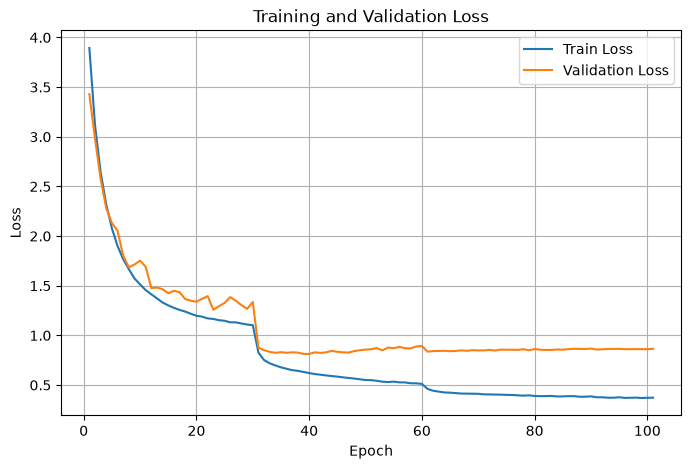

In [105]:
## printing the plots
import matplotlib.pyplot as plt
epochs = range(1, len(train_losses) + 1)
# ==========================================
# Loss Plot
# ==========================================
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig(
    output_dir / "loss.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()
plt.close()

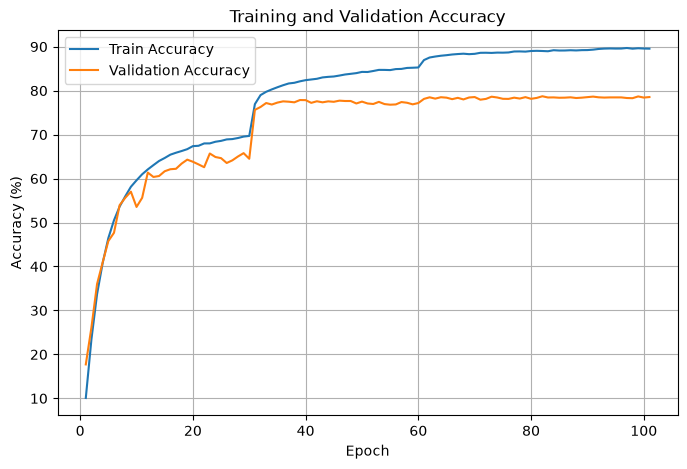

In [106]:
# ==========================================
# Accuracy Plot
# ==========================================
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.savefig(
    output_dir / "accuracy.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()
plt.close()

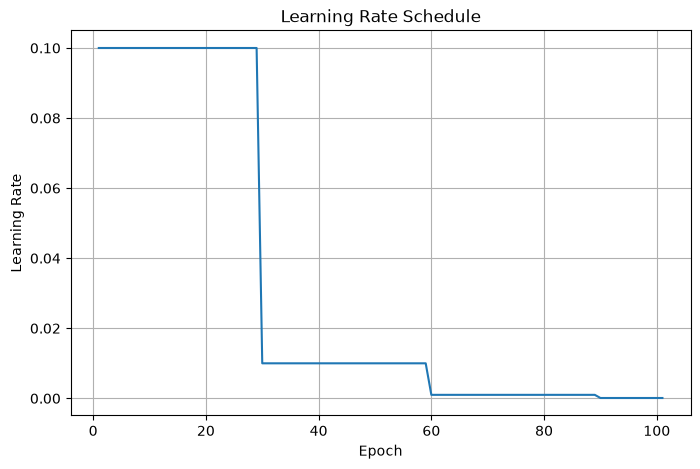

In [107]:
# ==========================================
# Learning Rate Plot
# ==========================================
plt.figure(figsize=(8, 5))
plt.plot(epochs, learning_rates)
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Schedule")
plt.grid(True)
plt.savefig(
    output_dir / "learning_rate.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()
plt.close()

## Check Model Path

In [108]:
from pathlib import Path

checkpoint_path = Path("/workspace/checkpoints/resnet18_imagenet100_best.pth")

print("Exists:", checkpoint_path.exists())

if checkpoint_path.exists():
    print("Size (MB):", checkpoint_path.stat().st_size / (1024**2))

Exists: True
Size (MB): 42.90864086151123


## You can run the below code to check how much time will 1 epoch take to run

In [78]:
## Taking the Dataset Objects and wrapping them in our DataLoaders

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=8,                               # since we now have 9 vCPUs, we can parallelize the process of image pre processing
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2                            # means each worker can prepare 2 batches i.e 16 batches at once total
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=8,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2
)

In [79]:
model = ResNet18(num_classes=100)

## Loss function
criterion = nn.CrossEntropyLoss()

## Optimizer
optimizer = torch.optim.SGD(
    model.parameters(),
    lr = 0.1,
    momentum = 0.9,
    weight_decay = 1e-4
)

## Learning rate scheduler
scheduler = torch.optim.lr_scheduler.StepLR(        # scheduler will not change the gradient itself but rather the step size applied to it
    optimizer, 
    step_size = 30,                                            # after every 30 epochs, our scheduler will change the LR
    gamma = 0.1                                                # to 0.1 of the current rate, a constant scheduling pattern
    )

In [80]:
import time
model = model.to(device)
model.train()

start = time.time()

for batch_idx, (images, labels) in enumerate(train_loader):

    images = images.to(device, non_blocking=True)
    labels = labels.to(device, non_blocking=True)

    optimizer.zero_grad()

    outputs = model(images)
    loss = criterion(outputs, labels)

    loss.backward()
    optimizer.step()

    if batch_idx == 99:
        break

elapsed = time.time() - start

print(f"100 batches took: {elapsed / 60:.2f} minutes")
print(f"Average per batch: {elapsed / 100:.2f} seconds")
print(f"Estimated training time per epoch: {(elapsed / 100) * len(train_loader) / 60:.2f} minutes")

100 batches took: 0.49 minutes
Average per batch: 0.30 seconds
Estimated training time per epoch: 5.00 minutes


In [36]:
## for 0 workers - 
# 100 batches took: 6.06 minutes
# Average per batch: 3.63 seconds
# Estimated training time per epoch: 123.08 minutes

In [46]:
## for 8 workers - 
# 100 batches took: 0.21 minutes
# Average per batch: 0.13 seconds
# Estimated training time per epoch: 4.32 minutes

In [71]:
## for 8 workers, 256 batch, prefecth factor = 1 - 
# 100 batches took: 0.95 minutes
# Average per batch: 0.57 seconds
# Estimated training time per epoch: 4.81 minutes